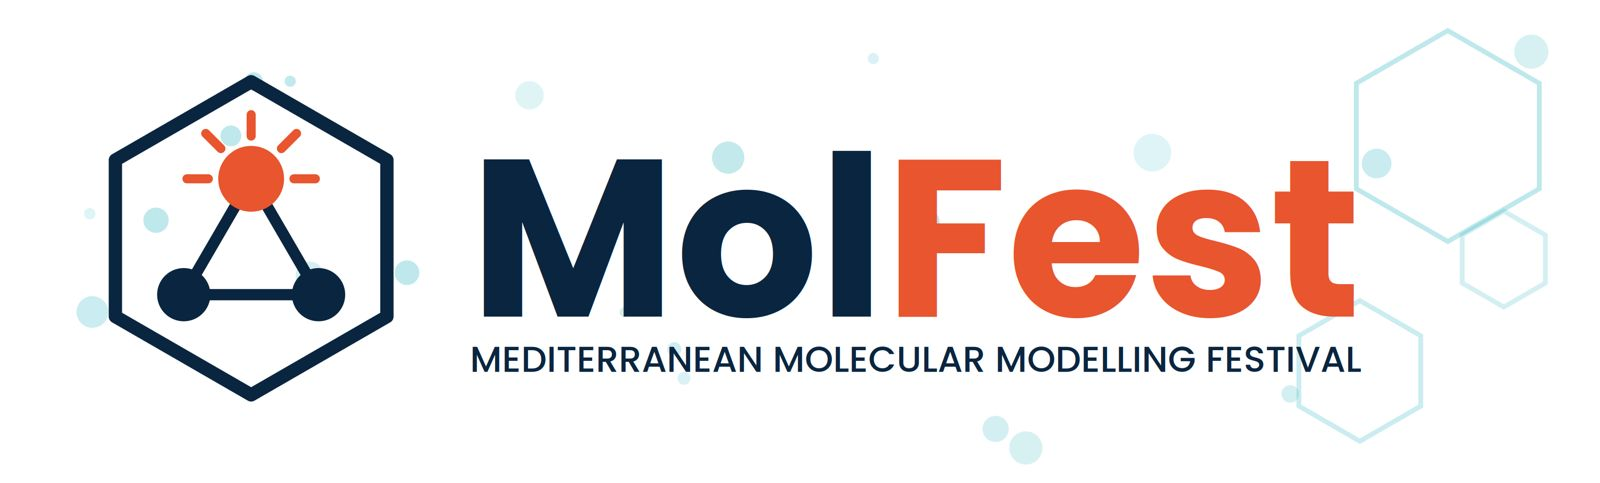


---

### Created by **Ekrem Yasar, PhD**

**MolFest — Mediterranean Molecular Modelling Festival** kapsamındaki *Sanal Tarama (Virtual Screening)* uygulamalı atölyesi için hazırlanmıştır. 📧 ey.biophysics@gmail.com

---

# 🧪 MolFest Workshop — PyRx ile Sanal Tarama için Ligand Hazırlığı

**Hedef protein:** ERα (Östrojen Reseptörü alfa) — PDB: **3UUD**

Bu notebook, ChEMBL veritabanından **FDA/EMA onaylı small-molecule ilaçları** çeker, aralarından **rastgele 100 tanesini** seçer ve bunları **RDKit** ile PyRx'te kullanılabilecek **SDF** formatına dönüştürür.

ChEMBL arayüzünden ilaçlar yalnızca CSV/TSV olarak indirilebildiği için, SDF üretimini RDKit ile biz yapacağız.

**Akış:**
1. Google Drive bağlama + `molfest_pyrx` klasörü oluşturma
2. ChEMBL'deki tüm fazların molekül sayıları (özet tablo)
3. Onaylı small-molecule ilaçları CSV olarak indirme
4. Rastgele 100 molekül seçme
5. RDKit ile 100 molekülü SDF'e dönüştürme (tek tek + birleşik dosya)

## 0️⃣ Gerekli kütüphanelerin kurulumu

Colab'da `rdkit` ve ChEMBL istemcisi (`chembl_webresource_client`) varsayılan olarak bulunmaz; bu hücrede kuruyoruz. Kurulum bittikten sonra bir sonraki hücreye geçebilirsiniz (yeniden başlatmaya gerek yok).

In [1]:
# Install the ChEMBL web resource client and RDKit (quiet mode)
!pip install -q chembl_webresource_client rdkit pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.4 MB/s eta 0:00:00


## 1️⃣ Google Drive'ı bağla ve `molfest_pyrx` klasörünü oluştur

Bu hücre Drive'ı bağlar ve çıktıların kaydedileceği `MyDrive/molfest_pyrx` klasörünü oluşturur. Çıkan bağlantıya tıklayıp Google hesabınıza izin vermeniz gerekir.

In [2]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Create the main working directory on Drive
BASE_DIR = '/content/drive/MyDrive/molfest_pyrx'
os.makedirs(BASE_DIR, exist_ok=True)

print('Calisma klasoru hazir:', BASE_DIR)

Mounted at /content/drive
Calisma klasoru hazir: /content/drive/MyDrive/molfest_pyrx


## 2️⃣ ChEMBL'deki tüm fazların molekül sayıları

Bu hücre, ChEMBL'de her klinik faz için (Faz 1, 2, 3 ve Onaylı) kaç molekül olduğunu ve bunların kaç tanesinin **small molecule** olduğunu sorgular. Sayımlar sunucu tarafında yapıldığı için hızlıdır. Sonuç bir özet tablo (DataFrame) olarak gösterilir.

> Not: `max_phase = 4` → onaylı ilaçlar (FDA/EMA). Bir sonraki hücrede bu grubu kullanacağız.

In [4]:
import pandas as pd
from chembl_webresource_client.new_client import new_client

molecule = new_client.molecule

# Map each clinical phase to a human-readable label (Turkish)
phase_labels = {
    4: 'Onayli (FDA/EMA)',
    3: 'Faz 3',
    2: 'Faz 2',
    1: 'Faz 1',
}

rows = []
for phase, label in phase_labels.items():
    # Server-side counts (fast, no full download)
    total = len(molecule.filter(max_phase=phase))
    small = len(molecule.filter(max_phase=phase, molecule_type='Small molecule'))
    rows.append({
        'max_phase': phase,
        'Aciklama': label,
        'Toplam_molekul': total,
        'Small_molecule': small,
    })

summary_df = pd.DataFrame(rows)

# Add a total row across all phases
total_row = {
    'max_phase': 'TUM FAZLAR',
    'Aciklama': 'Toplam (Faz 1-4)',
    'Toplam_molekul': summary_df['Toplam_molekul'].sum(),
    'Small_molecule': summary_df['Small_molecule'].sum(),
}
summary_df = pd.concat([summary_df, pd.DataFrame([total_row])], ignore_index=True)

print('ChEMBL faz bazinda molekul sayilari:')
summary_df

ChEMBL faz bazinda molekul sayilari:


,max_phase,Aciklama,Toplam_molekul,Small_molecule
0,4,Onayli (FDA/EMA),4225,3475
1,3,Faz 3,1892,1174
2,2,Faz 2,9054,7115
3,1,Faz 1,1613,978
4,TUM FAZLAR,Toplam (Faz 1-4),16784,12742


## 3️⃣ Onaylı small-molecule ilaçları ChEMBL'den çek ve kaydet

Bu hücre, **onaylı (max_phase = 4)** ve **small molecule** olan ilaçları ChEMBL ID, isim ve SMILES bilgileriyle birlikte indirir. SMILES'i olmayan kayıtlar (ör. bazı biyolojikler / eksik yapılar) elenir ve sonuç `molfest_pyrx` klasörüne CSV olarak kaydedilir.

> İndirme birkaç bin kaydı kapsadığı için bir kaç dakika sürebilir.

In [5]:
# Query approved (max_phase=4) small-molecule drugs; request only the fields we need
approved = molecule.filter(
    max_phase=4,
    molecule_type='Small molecule',
).only([
    'molecule_chembl_id',
    'pref_name',
    'max_phase',
    'molecule_type',
    'molecule_structures',
])

records = []
for m in approved:
    structures = m.get('molecule_structures')
    smiles = structures.get('canonical_smiles') if structures else None
    records.append({
        'chembl_id': m.get('molecule_chembl_id'),
        'pref_name': m.get('pref_name'),
        'smiles': smiles,
        'max_phase': m.get('max_phase'),
        'molecule_type': m.get('molecule_type'),
    })

drugs_df = pd.DataFrame(records)

# Drop records without a valid SMILES (cannot be docked)
drugs_df = drugs_df.dropna(subset=['smiles']).reset_index(drop=True)

# Save the full approved small-molecule set to Drive
all_csv_path = os.path.join(BASE_DIR, 'chembl_approved_small_molecules.csv')
drugs_df.to_csv(all_csv_path, index=False)

print('Toplam onayli small-molecule ilac (SMILES mevcut):', len(drugs_df))
print('CSV kaydedildi:', all_csv_path)
drugs_df.head()

Toplam onayli small-molecule ilac (SMILES mevcut): 3311
CSV kaydedildi: /content/drive/MyDrive/molfest_pyrx/chembl_approved_small_molecules.csv


,chembl_id,pref_name,smiles,max_phase,molecule_type
0,CHEMBL2,PRAZOSIN,COc1cc2nc(N3CCN(C(=O)c4ccco4)CC3)nc(N)c2cc1OC,4.0,Small molecule
1,CHEMBL3,NICOTINE,CN1CCC[C@H]1c1cccnc1,4.0,Small molecule
2,CHEMBL4,OFLOXACIN,CC1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23,4.0,Small molecule
3,CHEMBL5,NALIDIXIC ACID,CCn1cc(C(=O)O)c(=O)c2ccc(C)nc21,4.0,Small molecule
4,CHEMBL6,INDOMETHACIN,COc1ccc2c(c1)c(CC(=O)O)c(C)n2C(=O)c1ccc(Cl)cc1,4.0,Small molecule


## 4️⃣ Rastgele 100 molekül seç ve CSV kaydet

Bu hücre, önceki listeden **rastgele 100 molekül** seçer. `random_state=42` sabit tutulduğu için herkes aynı 100 molekülü alır (workshop tekrarlanabilirliği için). Seçim ayrı bir CSV olarak kaydedilir.

In [6]:
# Randomly sample 100 molecules (fixed seed for reproducibility)
sample_df = drugs_df.sample(n=100, random_state=42).reset_index(drop=True)

# Save the 100-molecule subset
sample_csv_path = os.path.join(BASE_DIR, 'random_100_molecules.csv')
sample_df.to_csv(sample_csv_path, index=False)

print('Secilen molekul sayisi:', len(sample_df))
print('CSV kaydedildi:', sample_csv_path)
sample_df.head()

Secilen molekul sayisi: 100
CSV kaydedildi: /content/drive/MyDrive/molfest_pyrx/random_100_molecules.csv


,chembl_id,pref_name,smiles,max_phase,molecule_type
0,CHEMBL30,CIMETIDINE,CN/C(=N\CCSCc1nc[nH]c1C)NC#N,4.0,Small molecule
1,CHEMBL291657,CRINECERFONT,C#CCN(c1nc(-c2cc(C)c(OC)cc2Cl)c(C)s1)[C@@H](CC...,4.0,Small molecule
2,CHEMBL477772,PAZOPANIB,Cc1ccc(Nc2nccc(N(C)c3ccc4c(C)n(C)nc4c3)n2)cc1S...,4.0,Small molecule
3,CHEMBL259209,MILNACIPRAN,CCN(CC)C(=O)C1(c2ccccc2)CC1CN,4.0,Small molecule
4,CHEMBL537,HYDROQUINONE,Oc1ccc(O)cc1,4.0,Small molecule


## 5️⃣ RDKit ile 100 molekülü SDF'e dönüştür

Bu hücre, `sdf_files` klasörünü oluşturur ve seçilen 100 molekülü RDKit ile işler:
- SMILES'ten molekül üretir, hidrojen ekler,
- **3B koordinat** üretir (ETKDGv3) ve MMFF ile enerji minimizasyonu yapar (docking için düz 2B yapılar uygun değildir),
- her molekülü **ayrı bir SDF** dosyasına yazar,
- ayrıca hepsini **tek bir birleşik SDF** dosyasına ekler.

Birleşik SDF (`molfest_100_ligands.sdf`), PyRx'in "Open Babel" penceresine doğrudan yüklenebilir.

In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem

# Create the folder for individual SDF files
SDF_DIR = os.path.join(BASE_DIR, 'sdf_files')
os.makedirs(SDF_DIR, exist_ok=True)

# Combined SDF that holds all 100 ligands (ideal for PyRx bulk import)
combined_sdf_path = os.path.join(BASE_DIR, 'molfest_100_ligands.sdf')
combined_writer = Chem.SDWriter(combined_sdf_path)

success, failed = 0, 0
for _, row in sample_df.iterrows():
    mol = Chem.MolFromSmiles(row['smiles'])
    if mol is None:
        failed += 1
        continue

    # Add hydrogens and generate a 3D conformation
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    if AllChem.EmbedMolecule(mol, params) != 0:
        failed += 1
        continue

    # Energy-minimize with the MMFF94 force field (best-effort)
    try:
        AllChem.MMFFOptimizeMolecule(mol)
    except Exception:
        pass

    # Attach useful metadata to the SDF record
    name = str(row['chembl_id'])
    mol.SetProp('_Name', name)
    mol.SetProp('ChEMBL_ID', name)
    if row['pref_name']:
        mol.SetProp('Pref_Name', str(row['pref_name']))
    mol.SetProp('SMILES', str(row['smiles']))

    # Write one SDF per molecule
    single_writer = Chem.SDWriter(os.path.join(SDF_DIR, f'{name}.sdf'))
    single_writer.write(mol)
    single_writer.close()

    # Append to the combined SDF
    combined_writer.write(mol)
    success += 1

combined_writer.close()

print(f'Basarili: {success} molekul  |  Basarisiz: {failed} molekul')
print('Tekil SDF klasoru :', SDF_DIR)
print('Birlesik SDF      :', combined_sdf_path)

[20:36:33] UFFTYPER: Unrecognized charge state for atom: 1
[20:36:35] UFFTYPER: Unrecognized atom type: Xe3+4 (0)
[20:36:38] UFFTYPER: Unrecognized atom type: Ca+2 (0)


Basarili: 100 molekul  |  Basarisiz: 0 molekul
Tekil SDF klasoru : /content/drive/MyDrive/molfest_pyrx/sdf_files
Birlesik SDF      : /content/drive/MyDrive/molfest_pyrx/molfest_100_ligands.sdf


## ✅ Sonraki adımlar (PyRx'te)

1. **Reseptör:** RCSB'den `3UUD` yapısını indirin, PyMOL/PyRx'te suları ve fazladan zincirleri temizleyin, doğal ligandı çıkarın → AutoDock için makromolekül (PDBQT) olarak yükleyin.
2. **Ligandlar:** `molfest_100_ligands.sdf` dosyasını PyRx → *Open Babel* ile içe aktarın, enerji minimizasyonu + PDBQT'ye dönüştürme yapın.
3. **Grid kutusu:** 3UUD'de doğal ligand (bağlanma cebi) etrafında grid kutusunu ayarlayın.
4. **Vina Wizard:** taramayı başlatın ve `binding affinity` değerlerine göre sonuçları sıralayın.

Tüm çıktı dosyaları `MyDrive/molfest_pyrx` içindedir. Kolay gelsin! 🎉